In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lime
import lime.lime_tabular

In [5]:
fold_1_train = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/berniss/Downloads/data/preprocessed/fold_5_val.csv')

In [6]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [7]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [8]:
# Scale using training fold only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [9]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [10]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

xgb_model.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:21:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [11]:
# Get fraud probabilities
rf_probs = rf_model.predict_proba(X_val_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]

In [12]:
# Blending (adjust weights as needed)
blended_probs = 0.5 * rf_probs + 0.5 * xgb_probs

# Convert to binary prediction with threshold
threshold = 0.5  # Tune this if needed
blended_preds = (blended_probs >= threshold).astype(int)

In [13]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        # AUC-PR (best for imbalanced problems)
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        # PR Curve
        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

Classification Report:
              precision    recall  f1-score   support

           0     0.9984    1.0000    0.9992    178711
           1     1.0000    0.8479    0.9177      1920

    accuracy                         0.9984    180631
   macro avg     0.9992    0.9240    0.9584    180631
weighted avg     0.9984    0.9984    0.9983    180631


Confusion Matrix:
[[178711      0]
 [   292   1628]]

Precision: 1.0000
Recall:    0.8479
F1 Score:  0.9177
AUC-PR (Average Precision): 1.0000


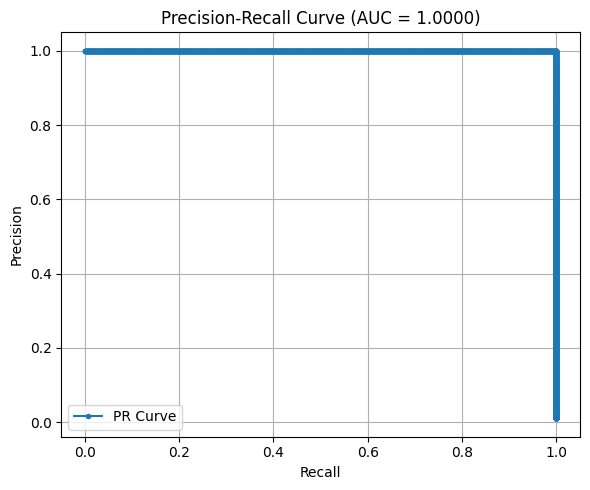

In [14]:
# Evaluate ensemble model
metrics = evaluate_model(y_val, blended_preds, y_proba=blended_probs, plot_pr_curve=True)

### Optuna Hyperparameter Tuning

In [15]:
# Objective function for Optuna
def create_objective(X_train, y_train, X_val, y_val):
    def objective(trial):
        rf = RandomForestClassifier(
            n_estimators=trial.suggest_int('rf_n_estimators', 50, 300),
            max_depth=trial.suggest_int('rf_max_depth', 3, 20),
            min_samples_split=trial.suggest_int('rf_min_samples_split', 2, 20),
            random_state=42,
            n_jobs=-1
        )

        xgb = XGBClassifier(
            n_estimators=trial.suggest_int('xgb_n_estimators', 50, 300),
            max_depth=trial.suggest_int('xgb_max_depth', 3, 15),
            learning_rate=trial.suggest_float('xgb_learning_rate', 0.01, 0.3),
            subsample=trial.suggest_float('xgb_subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0),
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        )

        blend_weight = trial.suggest_float('blend_weight', 0.1, 0.9)

        rf.fit(X_train, y_train)
        xgb.fit(X_train, y_train)

        rf_probs = rf.predict_proba(X_val)[:, 1]
        xgb_probs = xgb.predict_proba(X_val)[:, 1]
        blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

        return average_precision_score(y_val, blended_probs)
    return objective

In [16]:
# Load your folds
def load_fold_data():
    train_folds = []
    val_folds = []
    for i in range(1, 6):
        train_folds.append(pd.read_csv(f'/Users/berniss/Downloads/data/preprocessed/fold_{i}_train.csv'))
        val_folds.append(pd.read_csv(f'/Users/berniss/Downloads/data/preprocessed/fold_{i}_val.csv'))
    return train_folds, val_folds

train_folds, val_folds = load_fold_data()

In [17]:
tuned_params_per_fold = []

# Tune with folds 1–4
for i in range(4):
    print(f"\nTuning Fold {i+1} (Validation)")

    train_data = pd.concat([df for j, df in enumerate(train_folds[:4]) if j != i])
    val_data = val_folds[i]

    X_train = train_data.drop(columns='fraud_bool')
    y_train = train_data['fraud_bool']
    X_val = val_data.drop(columns='fraud_bool')
    y_val = val_data['fraud_bool']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Sample 1 million rows while preserving the 50/50 balance
    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train_scaled,
        y_train,
        train_size=1_000_000,
        stratify=y_train,
        random_state=42
    )

    study = optuna.create_study(direction='maximize')
    study.optimize(create_objective(X_train_sample, y_train_sample, X_val_scaled, y_val), n_trials=10, show_progress_bar=True)
    
    tuned_params_per_fold.append(study.best_params)



Tuning Fold 1 (Validation)


[I 2025-04-17 07:25:28,854] A new study created in memory with name: no-name-2e88e693-125f-41d3-a230-3610a86aad0b


  0%|          | 0/10 [00:00<?, ?it/s]

[W 2025-04-17 07:25:51,843] Trial 0 failed with parameters: {'rf_n_estimators': 72, 'rf_max_depth': 8, 'rf_min_samples_split': 5, 'xgb_n_estimators': 65, 'xgb_max_depth': 3, 'xgb_learning_rate': 0.1493569255406307, 'xgb_subsample': 0.6644751243710354, 'xgb_colsample_bytree': 0.5510159303802639, 'blend_weight': 0.6167639055096409} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/12/q4wqxhts38d3xk830pbsm9kh0000gp/T/ipykernel_88548/1997466519.py", line 26, in objective
    rf.fit(X_train, y_train)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

KeyboardInterrupt: 

In [ ]:
all_metrics = []

for i in range(4):
    print(f"\nEvaluating Fold {i+1} with Tuned Parameters")

    train_data = pd.concat([df for j, df in enumerate(train_folds[:4]) if j != i])
    val_data = val_folds[i]

    X_train = train_data.drop(columns='fraud_bool')
    y_train = train_data['fraud_bool']
    X_val = val_data.drop(columns='fraud_bool')
    y_val = val_data['fraud_bool']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    best_params = tuned_params_per_fold[i]
    blend_weight = best_params['blend_weight']

    best_rf = RandomForestClassifier(
        n_estimators=best_params['rf_n_estimators'],
        max_depth=best_params['rf_max_depth'],
        min_samples_split=best_params['rf_min_samples_split'],
        random_state=42,
        n_jobs=-1
    )
    best_xgb = XGBClassifier(
        n_estimators=best_params['xgb_n_estimators'],
        max_depth=best_params['xgb_max_depth'],
        learning_rate=best_params['xgb_learning_rate'],
        subsample=best_params['xgb_subsample'],
        colsample_bytree=best_params['xgb_colsample_bytree'],
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    best_rf.fit(X_train_scaled, y_train)
    best_xgb.fit(X_train_scaled, y_train)

    rf_probs = best_rf.predict_proba(X_val_scaled)[:, 1]
    xgb_probs = best_xgb.predict_proba(X_val_scaled)[:, 1]
    blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

    thresholds = np.linspace(0.01, 0.99, 100)
    best_thresh = thresholds[np.argmax([average_precision_score(y_val, (blended_probs >= t).astype(int)) for t in thresholds])]
    final_preds = (blended_probs >= best_thresh).astype(int)

    metrics = evaluate_model(y_val, final_preds, blended_probs)
    metrics['threshold'] = best_thresh
    all_metrics.append(metrics)

    print(f"Fold {i+1} Metrics:", metrics)

In [ ]:
# Average hyperparameters across folds
from statistics import mean

def average_params(tuned_params_list):
    numeric_keys = ['rf_n_estimators', 'rf_max_depth', 'rf_min_samples_split',
                    'xgb_n_estimators', 'xgb_max_depth', 'xgb_learning_rate',
                    'xgb_subsample', 'xgb_colsample_bytree', 'blend_weight']
    
    avg_params = {
        key: mean([params[key] for params in tuned_params_list]) for key in numeric_keys
    }
    # Round where appropriate
    int_keys = ['rf_n_estimators', 'rf_max_depth', 'rf_min_samples_split',
                'xgb_n_estimators', 'xgb_max_depth']
    for key in int_keys:
        avg_params[key] = int(round(avg_params[key]))
    
    return avg_params

final_params = average_params(tuned_params_per_fold)
blend_weight = final_params['blend_weight']

In [ ]:
# Display the best hyperparameters after averaging across folds
print("Averaged Hyperparameters Across Folds:")
print(f"Random Forest - n_estimators: {final_params['rf_n_estimators']}")
print(f"Random Forest - max_depth: {final_params['rf_max_depth']}")
print(f"Random Forest - min_samples_split: {final_params['rf_min_samples_split']}")
print(f"XGBoost - n_estimators: {final_params['xgb_n_estimators']}")
print(f"XGBoost - max_depth: {final_params['xgb_max_depth']}")
print(f"XGBoost - learning_rate: {final_params['xgb_learning_rate']}")
print(f"XGBoost - subsample: {final_params['xgb_subsample']}")
print(f"XGBoost - colsample_bytree: {final_params['xgb_colsample_bytree']}")
print(f"Blend Weight: {final_params['blend_weight']}")

In [ ]:
# Train final models
final_rf = RandomForestClassifier(
    n_estimators=final_params['rf_n_estimators'],
    max_depth=final_params['rf_max_depth'],
    min_samples_split=final_params['rf_min_samples_split'],
    random_state=42,
    n_jobs=-1
)

final_xgb = XGBClassifier(
    n_estimators=final_params['xgb_n_estimators'],
    max_depth=final_params['xgb_max_depth'],
    learning_rate=final_params['xgb_learning_rate'],
    subsample=final_params['xgb_subsample'],
    colsample_bytree=final_params['xgb_colsample_bytree'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)


In [ ]:
final_rf.fit(X_train_scaled, y_train)

In [ ]:
final_xgb.fit(X_train_scaled, y_train)

In [ ]:
# Predict and optimize threshold
rf_probs = final_rf.predict_proba(X_val_scaled)[:, 1]
xgb_probs = final_xgb.predict_proba(X_val_scaled)[:, 1]
blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

thresholds = np.linspace(0.01, 0.99, 100)
best_thresh = thresholds[np.argmax([
    average_precision_score(y_val, (blended_probs >= t).astype(int)) for t in thresholds
])]

final_preds = (blended_probs >= best_thresh).astype(int)

# Final metrics
final_metrics = evaluate_model(y_val, final_preds, blended_probs)
final_metrics['threshold'] = best_thresh

print("Final Evaluation on Fold 5:")
print(final_metrics)


In [ ]:
# Use this if not already scaled
feature_names = X_val.columns.tolist()
class_names = ['Not Fraud', 'Fraud']

# Function to use for LIME (blended probability output)
def blended_predict_proba(X):
    X_scaled = scaler.transform(X)
    rf_probs = final_rf.predict_proba(X_scaled)[:, 1]
    xgb_probs = final_xgb.predict_proba(X_scaled)[:, 1]
    blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs
    return np.vstack([1 - blended_probs, blended_probs]).T  # LIME expects probs for both classes

# Instantiate LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode='classification'
)

# Choose a sample instance from validation
for i in [0, 10, 25]:  # Select a few indices of interest
    exp = explainer.explain_instance(X_val.iloc[i].values, blended_predict_proba, num_features=10)
    exp.show_in_notebook(show_table=True, show_all=False)